# Two levers for 04's two limits: a unit-conversion tool and a scan line

`04` converged at test reward 0.844, and its seed had 0.833 of that. What the converged policy still
got wrong was measured item by item from its own answers on the 240 test questions (the code below
reproduces the count): of 102 limits it had to convert before comparing, it copied the user's number
unconverted on 91 and converted 0 right; on 33 of the 63 questions stated in °F, ft², t/h or m³/h its
arguments landed 1-2.5% off, past the 0.5% tolerance; and on 5 of the 13 scans it answered wrong
after the right simulations it had been asked for the *highest* passing setting and gave the first.
The comparison itself, given the numbers it wrote, was right on 1,197 of 1,200 items.

This notebook changes two things and reruns the recipe. **A tool, `convert_units`**, does the
conversions the model was doing in its head (03 and 02's lesson again: what a 0.8B model cannot
compute, give it a tool for). **A line in the answer's reasoning** names the passing candidates and
the one the question's objective picks, so the decision is a copy of something the model has just
written. The questions are 04's, regenerated because 04's factor for A in LMH/bar was 1000x too large;
1,680 of 1,800 prompts are 04's byte for byte and the 120 that differ are exactly
the ones stating A in LMH/bar.

**Held out, greedy, answers stopped at their closing brace:**

| policy | test reward | decision right | whole answer right | proving simulations |
| --- | --- | --- | --- | --- |
| 04: the label seed | 0.833 | 0.812 | 0.696 | 0.867 |
| 04: PPO, best of 500 steps | 0.844 | 0.838 | 0.762 | 0.854 |
| 05: the label seed, with the tool and the line | 0.916 | 0.908 | 0.817 | 0.983 |
| 05: PPO, best of 244 steps | 0.920 | 0.908 | 0.846 | 0.988 |

| policy | holdout_shift reward | decision right | whole answer right | proving simulations |
| --- | --- | --- | --- | --- |
| 04: the label seed | 0.670 | 0.567 | 0.442 | 0.800 |
| 04: PPO | 0.657 | 0.592 | 0.408 | 0.742 |
| 05: the label seed | 0.699 | 0.592 | 0.450 | 0.892 |
| 05: PPO | 0.739 | 0.650 | 0.517 | 0.900 |

On the 221 test questions the two notebooks share word for word: 04's PPO reward 0.854
(decisions 0.842, whole answer 0.778), 05's seed 0.922
(0.914, 0.824), 05's PPO 0.929 (0.919, 0.860).

**The seed did it again.** With the tool and the line, the seed alone reaches test reward
0.916 (04's seed: 0.833; 04's PPO: 0.844). PPO adds
+0.004 reward and
+0.000 decisions on test
(right only under PPO 10, only under the seed 10; McNemar p = 1.00).

- **The tool is served here, not on the deployed server.** `convert_units` is declared to the model
  exactly like the two simulators and run by the same host; the MCP server on temur does not have it
  yet, so a policy trained here needs it added there before it can be deployed.
- **The seed labels one more thing than 04's**: the limit in each comparison line. 04 left the limits
  to PPO as content and the policy copied the user's number; here the right number sits in the
  convert tool's response, and copying it is scaffolding, not judgement. The simulated values and the
  JSON's content are left to PPO as before; the decision is labelled on 2 train records per answer
  class, 04's dose.
- Convert calls earn nothing and cost nothing: outside the calls credit, the efficiency count and the
  8-simulation budget. The policy's token budget is 2,048 (04: 1,536).


In [1]:
import collections, importlib.util, json, math, re, statistics as st, sys
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "05_units_and_scans.py").exists() else Path("experiments/notebooks/smoke_test35")
# This notebook's own module (04's, copied and changed as the header says); loaded by path because the
# file name starts with a digit. Scoring, the tool and the checks are pure Python: nothing below needs
# WaterTAP or a GPU.
spec = importlib.util.spec_from_file_location("nw05", HERE / "05_units_and_scans.py")
nw = importlib.util.module_from_spec(spec)
sys.modules["nw05"] = nw
spec.loader.exec_module(nw)
RUNS, RUNS04 = nw.RUNS, HERE / "04_natural_watertap_runs"
splits = {s: nw.load_split(s) for s in nw.SPLITS}
checks = json.loads((HERE / "05_units_and_scans_checks.json").read_text())


def rows_of(path):
    return [json.loads(line) for line in Path(path).read_text().splitlines()]


def cases_of(split, data_dir=None):
    d = data_dir or nw.DATA
    return {c["id"]: c for c in map(json.loads, (d / f"{split}.jsonl").read_text().splitlines())}


print({s: len(c) for s, c in splits.items()}, "| tools:", ", ".join(nw.ALL_TOOLS))

{'train': 1200, 'dev': 240, 'test': 240, 'holdout_shift': 120} | tools: simulate_ro, simulate_swro_system, convert_units


## What 04's policy got wrong, item by item

Every comparison line the policy writes has the form `field value meets|breaks op limit`, one item per
limit, and the answer's decision follows the verdicts. Parsing 04's own test answers, each item's
limit is checked against the scenario's threshold in the tool's units, and its verdict against the
truth; a limit that had to be converted from the user's unit is either right, the user's number
copied unconverted, or something else. The proving simulations are 04's `evidence`; the scan
aggregation is whether the setting answered is the one the written verdicts and the question's
objective pick.


In [2]:
ITEM = re.compile(r"(?P<metric>[\w.]+) (?P<value>-?[\d.]+(?:e-?\d+)?) (?P<verdict>meets|breaks) (?P<op><=|>=) (?P<limit>-?[\d.]+(?:e-?\d+)?)")
LINE = re.compile(r"^(?P<label>[^:]+):\s*(?P<body>.*?)\s*->\s*(?P<verdict>pass|fail)\s*$")
AGG = re.compile(r"^passing: (?P<set>.+?) -> (?P<word>\w+): (?P<pick>.+)$", re.M)


def rel(a, b):
    return abs(a - b) / max(abs(b), 1e-9)


def decompose(path, cases):
    """Item-by-item account of a probe's episodes: limits, comparison logic, proving simulations by
    unit level, scan aggregation, wrong decisions by source."""
    c_ = collections.Counter()
    lvl = collections.defaultdict(collections.Counter)
    for ep in rows_of(path):
        case = cases[ep["id"]]
        L = lvl[case["level"]]
        L["n"] += 1
        L["evidence"] += bool(ep["score"]["evidence"])
        L["decision"] += bool(ep["score"]["decision_correct"])
        thr = {k["metric"]: k for k in case["constraints"]}
        pts = {p["label"]: p for p in case["points"]} if case["decision_kind"] != "passfail" else {"Result": case["points"][0]}
        text = ep["final_text"].split("{")[0]
        written = {}
        for ln in text.splitlines():
            m = LINE.match(ln.strip())
            if not m or m["label"].strip() not in pts:
                continue
            written[m["label"].strip()] = m["verdict"]
            p = pts[m["label"].strip()]
            for it in ITEM.finditer(m["body"]):
                k = thr.get(it["metric"])
                if k is None or it["metric"] not in p["metrics"]:
                    continue
                c_["items"] += 1
                lim, v = float(it["limit"]), float(it["value"])
                tv, tl = p["metrics"][it["metric"]], k["threshold"]
                needs = rel(k["user_value"], tl) > 0.005
                if needs:
                    c_["limits needing conversion"] += 1
                    c_["  written right"] += rel(lim, tl) <= 0.005
                    c_["  the user's number copied"] += rel(lim, tl) > 0.005 and rel(lim, k["user_value"]) <= 0.005
                true_meets = (tv >= tl) if k["op"] == ">=" else (tv <= tl)
                if (it["verdict"] == "meets") == true_meets:
                    c_["verdict right"] += 1
                elif rel(lim, tl) > 0.005:
                    c_["verdict wrong: limit wrong"] += 1
                elif rel(v, tv) > 0.02:
                    c_["verdict wrong: value wrong"] += 1
                elif it["op"] != k["op"]:
                    c_["verdict wrong: operator wrong"] += 1
                else:
                    c_["verdict wrong: comparison"] += 1
        if case["decision_kind"] == "number" and ep["score"]["evidence"] and not ep["score"]["decision_correct"]:
            order = [p["label"] for p in case["points"]]
            passing = [l for l in order if written.get(l) == "pass"]
            want = (passing[0] if case["objective"] == "lowest" else passing[-1]) if passing else "none"
            obj = nw.extract_answer(ep["final_text"])[0] or {}
            d = obj.get("decision")
            said = "none" if nw._none_like(d) else str(d)
            wrong_verdict = any((written.get(l) == "pass") != all(
                (p["metrics"][k["metric"]] >= k["threshold"]) if k["op"] == ">=" else (p["metrics"][k["metric"]] <= k["threshold"])
                for k in case["constraints"]) for l, p in pts.items() if l in written)
            c_["scan wrong after right sims"] += 1
            c_["  a verdict wrong"] += wrong_verdict
            c_["  verdicts right, pick wrong"] += (not wrong_verdict) and said != want
            c_["  verdicts and pick right, decision differs"] += (not wrong_verdict) and said == want
        if not ep["score"]["decision_correct"]:
            c_["wrong decisions"] += 1
            if nw.extract_answer(ep["final_text"])[0] is None:
                c_["  no answer"] += 1
            elif not ep["score"]["evidence"]:
                c_["  proving simulation missing"] += 1
            else:
                c_["  after the right simulations"] += 1
    return c_, lvl


def show(title, path, cases):
    c_, lvl = decompose(path, cases)
    print(f"== {title}")
    for k in ("items", "verdict right", "verdict wrong: limit wrong", "verdict wrong: value wrong",
              "verdict wrong: operator wrong", "verdict wrong: comparison", "limits needing conversion",
              "  written right", "  the user's number copied", "wrong decisions", "  no answer",
              "  proving simulation missing", "  after the right simulations", "scan wrong after right sims",
              "  a verdict wrong", "  verdicts right, pick wrong", "  verdicts and pick right, decision differs"):
        print(f"   {k:46} {c_.get(k, 0)}")
    for l in sorted(lvl):
        L = lvl[l]
        print(f"   unit level {l}: n {L['n']:3}, proving simulations {L['evidence'] / L['n']:.3f}, decisions {L['decision'] / L['n']:.3f}")
    return c_, lvl


test04 = cases_of("test", nw.DATA_04)
d04 = {}
for name, path in (("04's label seed, test", RUNS04 / "label-seed-pc2" / "epoch3" / "test-T0-stop.episodes.jsonl"),
                   ("04's PPO best, test", RUNS04 / "ppo-s0" / "best" / "test-T0-stop.episodes.jsonl")):
    d04[name] = show(name, path, test04)
    print()

== 04's label seed, test
   items                                          1378
   verdict right                                  1315
   verdict wrong: limit wrong                     49
   verdict wrong: value wrong                     4
   verdict wrong: operator wrong                  0
   verdict wrong: comparison                      10
   limits needing conversion                      132
     written right                                1
     the user's number copied                     101
   wrong decisions                                45
     no answer                                    1
     proving simulation missing                   14
     after the right simulations                  30
   scan wrong after right sims                    18
     a verdict wrong                              9
     verdicts right, pick wrong                   9
     verdicts and pick right, decision differs    0
   unit level 0: n 104, proving simulations 1.000, decisions 0.913
   unit 

## The tool

`convert_units(value, from_unit, to_unit)` returns `{"value": ..., "unit": ...}` at six significant
figures, or `{"error": ...}` -- the simulators' own convention. Its factors are the generator's,
so a converted number is the scenario's argument to 6 figures (the argument tolerance is 0.5%; the
gold margins are 2%). It accepts the spellings the prompts use (°F, ft², m³/h, ‰, "% salt by mass",
"$ per 1,000 gallons") and the usual variants. It takes no unit the questions never use.

The declaration the model sees is the third in the tool list, in the same format as the two the
server serves; it adds about 300 tokens to every prompt.

One factor in 04's generator was wrong: A in LMH/bar used 3.6e14, and the questions said things like
"A = 1019.72 LMH/bar". 1 m/s is 3.6e6 LMH and 1 bar is 1e5 Pa, so the factor is 3.6e11 and a
membrane with A = 3.2e-12 m/s/Pa has 1.15 LMH/bar. The tool is physically right, so the questions
had to be regenerated; the cases are independent draws, and only those stating A in LMH/bar change.


In [3]:
decls = json.loads(nw.TOOLS_JSON.read_text())
print("tools declared:", [d["function"]["name"] for d in decls])
print(json.dumps(nw.CONVERT_DECL["function"], indent=1, ensure_ascii=False)[:1400], "\n")
for args in [(77, "°F", "C"), (3700, "ft²", "m2"), (16, "gfd", "LMH"), (5, "m³/h", "kg/s"), (5, "m³/h", "m³/s"),
             (1.2, "$ per 1,000 gallons", "$/m3"), (3.29, "% salt by mass", "mass fraction"), (85, "%", "fraction"),
             (1.02, "LMH/bar", "m/s/Pa"), (900, "psi", "bar"), (20, "L/m²/h", "LMH"), (7, "kPa", "furlongs")]:
    print(f"  convert_units{args!s:40} -> {nw.convert_units(*args)}")
# Every conversion the generator can state, against the generator's own factor.
n, bad = 0, 0
for q, units in nw.INPUT_UNITS.items():
    for u in units:
        if nw.needs_conversion(u):
            for user in (1.0, 37.5, 1234.0):
                got = json.loads(nw.convert_units(user, nw.UNIT_SYMBOL[u["name"]], nw.TOOL_UNIT[q]))["value"]
                n += 1
                bad += abs(got - nw.to_tool(u, user)) > 1e-5 * abs(nw.to_tool(u, user))
for path, units in nw.METRIC_UNITS.items():
    for u in units:
        if nw.needs_conversion(u):
            for user in (1.0, 37.5, 1234.0):
                got = json.loads(nw.convert_units(user, nw.UNIT_SYMBOL[u["name"]], nw.METRIC_TOOL_UNIT[path]))["value"]
                n += 1
                bad += abs(got - nw.to_tool(u, user)) > 1e-5 * abs(nw.to_tool(u, user))
print(f"\n{n} conversions the generator can state: {bad} differ from its factor by more than 1e-5")
old, new = 3.6e14, nw.unit_spec("A", "LMH/bar")["factor"]
print(f"A = 3.2e-12 m/s/Pa in LMH/bar: 04 said {3.2e-12 * old:.2f}, the corrected factor {new:.1e} gives {3.2e-12 * new:.2f}")
import warnings
warnings.filterwarnings("ignore")
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(nw.MODEL, padding_side="left")
c0 = splits["dev"][0]
n5 = len(tok(nw.render_prompt(tok, c0), add_special_tokens=False).input_ids)
nw._DECLS = json.loads((HERE / "04_natural_watertap_tools.json").read_text())
n4 = len(tok(nw.render_prompt(tok, c0), add_special_tokens=False).input_ids)
nw._DECLS = None
print(f"prompt tokens for {c0['id']}: {n4} with the two simulators, {n5} with convert_units declared too")

tools declared: ['simulate_ro', 'simulate_swro_system', 'convert_units']
{
 "name": "convert_units",
 "description": "Convert one number between units.\n\nSupported: mass flow (kg/s, t/h, kg/h; m3/h and m3/d of water at 1000 kg/m3), volume flow (m3/s, L/s, m3/h, m3/d, MGD), salinity as a mass fraction (mass fraction, g/kg, ‰, %, mg/kg, ppm), concentration (g/L, mg/L, kg/m3, ppm), temperature (C, F), area (m2, ft2), pressure (bar, kPa, MPa, psi), water permeability A (m/s/Pa, LMH/bar), salt permeability B (m/s, LMH), flux (LMH, gfd), cost ($/m3, $/kgal), efficiency (fraction, %).\n\nReturns JSON {\"value\": ..., \"unit\": ...}. On failure returns {\"error\": ...} rather than raising.\n",
 "parameters": {
  "properties": {
   "value": {
    "title": "Value",
    "type": "number"
   },
   "from_unit": {
    "title": "From Unit",
    "type": "string"
   },
   "to_unit": {
    "title": "To Unit",
    "type": "string"
   }
  },
  "required": [
   "value",
   "from_unit",
   "to_unit"
  ],
  

prompt tokens for ro_check-dev-00000: 2083 with the two simulators, 2392 with convert_units declared too


## The questions, regenerated

Same generator, same seeds, one factor corrected, and every stated input now recorded with the unit
it was stated in (so a reference episode knows what to convert). Decontamination against the
benchmark is repeated.


In [4]:
same = checks["identical_to_04"]
print(f"{'split':14} {'cases':>6} {'identical to 04':>16} {'state A in LMH/bar':>19}")
for s, v in same.items():
    print(f"{s:14} {v['n']:>6} {v['identical_prompt']:>16} {v['lmh_bar_cases']:>19}")
tot = sum(v["n"] for v in same.values())
print(f"{'all':14} {tot:>6} {sum(v['identical_prompt'] for v in same.values()):>16} {sum(v['lmh_bar_cases'] for v in same.values()):>19}")
d = checks["decontamination"]
print(f"\nbenchmark 8-grams: {d['benchmark_8grams']:,}; generated prompts sharing any: {d['prompts_with_any_8gram']}; "
      f"cases reusing a benchmark scenario: {d['cases_reusing_a_benchmark_scenario']}")
print("scenarios shared between splits:", checks["cross_split_scenarios"], "| duplicate prompts:", checks["duplicate_prompts"])
print("\nunit level of the cases (highest level any quantity in the question uses):")
for s, cs in splits.items():
    print(f"  {s:14}", dict(sorted(collections.Counter(c["level"] for c in cs).items())))
print("\ntrain: decisions per family (the target is drawn before the scenario, as in 04)")
for fam in nw.FAMILIES:
    cs = [c for c in splits["train"] if c["family"] == fam]
    print(f"  {fam:17} n={len(cs)}  {dict(collections.Counter(nw.decision_label(c) for c in cs).most_common())}")

split           cases  identical to 04  state A in LMH/bar
train            1200             1123                  77
dev               240              226                  14
test              240              221                  19
holdout_shift     120              110                  10
all              1800             1680                 120

benchmark 8-grams: 105,943; generated prompts sharing any: 0; cases reusing a benchmark scenario: 0
scenarios shared between splits: {'dev&train': 0, 'dev&test': 0, 'dev&holdout_shift': 0, 'test&train': 0, 'holdout_shift&train': 0, 'holdout_shift&test': 0} | duplicate prompts: 0

unit level of the cases (highest level any quantity in the question uses):
  train          {0: 493, 1: 417, 2: 290}
  dev            {0: 95, 1: 87, 2: 58}
  test           {0: 104, 1: 73, 2: 63}
  holdout_shift  {0: 49, 1: 34, 2: 37}

train: decisions per family (the target is drawn before the scenario, as in 04)
  ro_check          n=200  {'fail': 103, 'pass':

## Reference episodes: convert, simulate, answer

04's blind reference episode simulated every candidate in one turn and then answered. Here it has a
turn before that when anything needs converting: one `convert_units` call per stated quantity whose
unit is not the tool's -- the shared inputs, each candidate's own input, each limit -- and the
simulate turn copies the converted numbers into its arguments. A relabel (L/m²/h for LMH, ppm for
mg/L) is not converted. On train, 2.21 conversions per case on average, at most
11, and 499 of 1,200 cases need none; the reference reward is 0.986
(04: 0.986; the difference is efficiency, unchanged).

The answer's reasoning gains one line after the candidates, in the choice families only:

    passing: 4.80 MPa, 5.10 MPa, 5.40 MPa, 5.70 MPa -> lowest: 4.80 MPa
    passing: A, B -> cheapest: A
    passing: A 3.38, B 3.016 -> lowest: B
    passing: none -> none

The membranes are quoted cheapest first, so `cheapest` is the first passing one; a plant option's
objective value is already on its line. The reference asserts that the line's pick is the gold
decision on every case.


In [5]:
refs = rows_of(nw.DATA / "train_reference.jsonl")
train_cases = cases_of("train")
conv = collections.Counter(r["converts"] for r in refs)
print(f"blind reference episodes on train: {len(refs)}, reward mean {st.mean(r['reward'] for r in refs):.3f}, "
      f"min {min(r['reward'] for r in refs):.3f}")
print("convert calls per case:", dict(sorted(conv.items())))
pairs = collections.Counter((c["from_unit"], c["to_unit"]) for r in refs for t in r["turns"] for c in
                            [x["arguments"] for x in t["calls"] if x["name"] == nw.CONVERT])
print("most common conversions:", ", ".join(f"{a} -> {b} ({n})" for (a, b), n in pairs.most_common(8)))
hc = json.loads((HERE / "05_units_and_scans_harness_checks.json").read_text())
print(f"\nharness checks on {hc['n']} dev reference episodes ({hc['episodes_by_call_turns']} by number of call turns, "
      f"{hc['convert_calls']} convert calls): calls that survive the XML round trip {hc['calls_parse_roundtrip']}/{hc['n']}; "
      f"token ids equal to the chat template's rendering {hc['token_ids_equal_template']}/{hc['n']}; "
      f"worker results identical to gold {hc['pool_results_identical_to_gold_exact_args']}/{hc['pool_calls']}")
ref = next(r for r in refs if train_cases[r["id"]]["family"] == "ro_scan_pressure" and len(r["turns"]) == 2
           and train_cases[r["id"]]["gold"]["decision"] is not None and train_cases[r["id"]]["level"] == 2)
c = train_cases[ref["id"]]
print(f"\n== {ref['id']} (unit level {c['level']})\n{c['prompt']}\n")
for t, turn in enumerate(ref["turns"]):
    calls = turn["calls"]
    print(f"-- turn {t + 1}: {len(calls)} {calls[0]['name']} call(s); the first, and its result:")
    print(nw.call_block(calls[0]["name"], calls[0]["arguments"]))
    print("<tool_response>", turn["results"][0][:160].replace("\n", " "), "...</tool_response>\n" if len(turn["results"][0]) > 160 else "</tool_response>\n")
print("-- the answer turn:")
print(ref["answer_reasoned"])

blind reference episodes on train: 1200, reward mean 0.986, min 0.943
convert calls per case: {0: 499, 1: 138, 2: 149, 3: 81, 4: 84, 5: 80, 6: 64, 7: 37, 8: 38, 9: 18, 10: 9, 11: 3}
most common conversions: kPa -> bar (390), MPa -> bar (352), % -> fraction (276), ft² -> m² (180), L/s -> m³/s (153), LMH -> m/s (127), °F -> C (126), LMH/bar -> m/s/Pa (121)

harness checks on 60 dev reference episodes ({'1': 28, '2': 32} by number of call turns, 118 convert calls): calls that survive the XML round trip 60/60; token ids equal to the chat template's rendering 60/60; worker results identical to gold 100/100

== ro_scan_pressure-train-00061 (unit level 2)
We're commissioning a new train and choosing its operating pressure. It's 31 °C at the intake. The rack holds 3,350 ft² of membrane. Feed salinity is 40,500 mg/kg. It runs on 8,210 kg/h of seawater feed.

Permeate NaCl has to stay at or below 1,000 ppm. We need at least 0.5 kg/s of permeate. Allowed setpoints run from 4.80 MPa to 6.00 MPa in

## The seed

04's label seed recipe: the calls turns and their `<|im_end|>` labelled; in the answer the
scaffolding, the verdict words and the JSON's syntax labelled, the simulated values and the JSON's
content left to PPO; the decision itself labelled on 2 train records per answer class. Two things are
added to what is labelled: the limit in each comparison line, and the whole aggregation line. Both are
copies -- of the convert tool's output or the prompt, and of the verdicts just written -- and the
first is the copy 04's policy got wrong.

Epoch 3 on dev: greedy reward 0.928, decisions 0.933, proving simulations 0.979;
sampled at T=1, two answers per question, 0.913, 0.915, 0.971. 04's label seed
sampled the same way: reward 0.807, decisions 0.756,
proving simulations 0.894. The gates PPO needs -- every answer class sampled
right, the level-2 questions' proving simulations, answers that parse -- are in the table below.


In [6]:
ref = next(r for r in refs if train_cases[r["id"]]["family"] == "ro_scan_pressure" and len(r["turns"]) == 2
           and train_cases[r["id"]]["gold"]["decision"] is not None)
ids, lab = nw.seed_example(train_cases[ref["id"]], ref, tok, label="scaffold", reasoning=True)
n = len(tok(ref["answer_reasoned"], add_special_tokens=False).input_ids) + 1
shown = "".join(tok.decode([t]) if l != -100 else "·" for t, l in zip(ids[0][-n:].tolist(), lab[0][-n:].tolist()))
print("an answer turn as the seed sees it (· = left to PPA):".replace("PPA", "PPO"))
print(re.sub("·+", "·", shown))
cfg = json.loads((RUNS / "label-seed-pc2" / "config.json").read_text())
print(f"\nlabel seed: {cfg['examples']} reference episodes, {cfg['epochs']} epochs, lr {cfg['lr']}, LoRA r{cfg['lora_r']}; "
      f"the decision labelled on {len(cfg['label_case_ids'])} records: {cfg['label_class_counts']}")

dev05, dev04 = cases_of("dev"), cases_of("dev", nw.DATA_04)
print()
for name, path, cases in (("05's seed, dev greedy", RUNS / "label-seed-pc2" / "epoch3" / "dev-T0-stop.episodes.jsonl", dev05),
                          ("05's seed, dev T=1 x2", RUNS / "label-seed-pc2" / "epoch3" / "dev-T1-x2-stop.episodes.jsonl", dev05),
                          ("04's seed, dev T=1 x2", RUNS04 / "label-seed-pc2" / "epoch3" / "dev-T1-x2-stop.episodes.jsonl", dev04)):
    o = json.loads(Path(path).with_name(Path(path).name.replace(".episodes.jsonl", ".json")).read_text())["overall"]
    print(f"== {name}: reward {o['reward']:.3f}, decisions {o['decision_correct']:.3f}, proving simulations {o['evidence']:.3f}, "
          f"answers {o['answer_found']:.3f}, converts/episode {o.get('converts_per_episode', 0):.2f} "
          f"(errored {o.get('converts_errored', 0):.3f})")
    show(name, path, cases)
    print()

# Which answers each seed says right, sampled (the gate: a class never said right cannot be learned).
def recall(path, cases):
    rec = collections.defaultdict(lambda: [0, 0])
    for r in rows_of(path):
        c = cases[r["id"]]
        cls = nw.decision_class(c) or c["gold"]["decision"]
        rec[(c["family"], cls)][1] += 1
        rec[(c["family"], cls)][0] += r["score"]["decision_correct"]
    return rec
order = [("ro_check", "fail"), ("ro_check", "pass"), ("swro_check", "fail"), ("swro_check", "pass"),
         ("ro_membrane", "A"), ("ro_membrane", "B"), ("ro_membrane", "C"), ("ro_membrane", "none"),
         ("swro_option", "A"), ("swro_option", "B"), ("swro_option", "C"), ("swro_option", "none"),
         ("ro_scan_area", "setting"), ("ro_scan_area", "none"), ("ro_scan_pressure", "setting"), ("ro_scan_pressure", "none")]
r05 = recall(RUNS / "label-seed-pc2" / "epoch3" / "dev-T1-x2-stop.episodes.jsonl", dev05)
r04 = recall(RUNS04 / "label-seed-pc2" / "epoch3" / "dev-T1-x2-stop.episodes.jsonl", dev04)
print(f"{'family':17} {'answer':8} {'04 seed':>10} {'05 seed':>10}   (right / sampled, T=1, two per dev question)")
for key in order:
    print(f"{key[0]:17} {key[1]:8} {r04[key][0]:>5}/{r04[key][1]:<4} {r05[key][0]:>5}/{r05[key][1]:<4}")

an answer turn as the seed sees it (· = left to PPO):
5.80 MPa: flux.water_LMH · meets <= 20; permeate.flow_kg_s · breaks >= 1.458; performance.salt_rejection_pct · meets >= 98 -> fail
6.00 MPa: flux.water_LMH · meets <= 20; permeate.flow_kg_s · breaks >= 1.458; performance.salt_rejection_pct · meets >= 98 -> fail
6.20 MPa: flux.water_LMH · meets <= 20; permeate.flow_kg_s · meets >= 1.458; performance.salt_rejection_pct · meets >= 98 -> pass
passing: 6.20 MPa -> highest: 6.20 MPa

{"decision": "·", "violations": [], "values": {"performance.salt_rejection_pct": ·, "flux.water_LMH": ·}}<|im_end|>

label seed: 1200 reference episodes, 3 epochs, lr 0.0001, LoRA r16; the decision labelled on 26 records: {'swro_option:B': 2, 'swro_option:none': 2, 'ro_scan_area:none': 2, 'ro_scan_pressure:setting': 2, 'ro_membrane:D': 2, 'ro_membrane:B': 2, 'ro_scan_pressure:none': 2, 'ro_scan_area:setting': 2, 'ro_membrane:none': 2, 'swro_option:A': 2, 'ro_membrane:A': 2, 'ro_membrane:C': 2, 'swro_option:C'

## PPO

04's configuration, unchanged except for what this notebook changes: it starts from this notebook's
label seed, the value head is warm-started at that seed's own sampled dev reward, and the token
budget is 2,048.

| setting | value | from |
| --- | --- | --- |
| start | the label seed, *k* = 2, epoch 3 | above |
| critic | value head on hidden layer 23, lr 9.19e-4, warm-started at the seed's sampled dev reward; 25 steps with the actor frozen | `02`, `04` |
| actor | LoRA r16, lr 1e-5, 4 inner epochs, clip 0.2; 8 train questions per step at T=1; gamma 1, lambda 0.95 | `03` |
| what the actor moves | the calls turns, and in the answer its content: simulated values, limits, verdicts, the aggregation line's set and pick, the decision, the violations, the numbers | `03`'s frozen scaffolding, plus this notebook's line |
| stabilisers | Adam eps 1e-6; KL 0.01 to the seed in the reward; answers stopped at their closing brace; turn-ending `<|im_end|>` out of the loss | `03` |
| gates | tool gate: sampled call fidelity below 0.90 over 10 steps stops the run; critic and no-regression gates; convergence: 8 evaluations without a new best, one evaluation of 120 dev questions every 25 steps | `03`, `04` |

**The run was stopped by its tool gate at step 244**, not by convergence: the sampled call
fidelity over the last 10 steps had fallen below 0.90 (0.883). Before that, the
evaluations on the 120 dev questions started at 0.9448 and stayed within a few hundredths of it --
3 of 9 later evaluations were above it, the best, step 175, at
0.9528 -- while the sampled training reward went the other way: 0.950 in steps
25-49, 0.896 in steps 200-224, then 0.699 with the calls at 0.927 in
the last window, where the simulator calls started coming back with errors and the answers stopped
parsing. The seed this run started from was already at 0.945; the policy gradient found
nothing to add at that level and, given time, took it apart. The best checkpoint is scored held out
below, next to the seed, as the run's result.


{'stopped_at': 244, 'reason': 'tool gate: sampled call fidelity over the last 10 steps 0.883 < 0.9', 'best_step': 175, 'best_reward': 0.9528406084656085}

 step  reward  decision  proving  violations  values  parses  critic - clock
    0   0.945     0.967    0.983       0.930   0.883   1.000               -
   25   0.945     0.967    0.983       0.930   0.883   1.000          +0.192
   50   0.942     0.942    0.983       0.954   0.932   1.000          +0.165
   75   0.945     0.950    0.975       0.966   0.937   0.992          +0.134
  100   0.947     0.950    0.975       0.946   0.956   1.000          +0.112
  125   0.912     0.900    0.983       0.906   0.888   1.000          +0.111
  150   0.907     0.883    0.983       0.925   0.898   1.000          +0.082
  175   0.953     0.958    0.992       0.959   0.947   1.000          +0.089
  200   0.885     0.867    0.967       0.906   0.874   0.992          +0.099
  225   0.915     0.917    0.942       0.959   0.922   0.992          +0.08

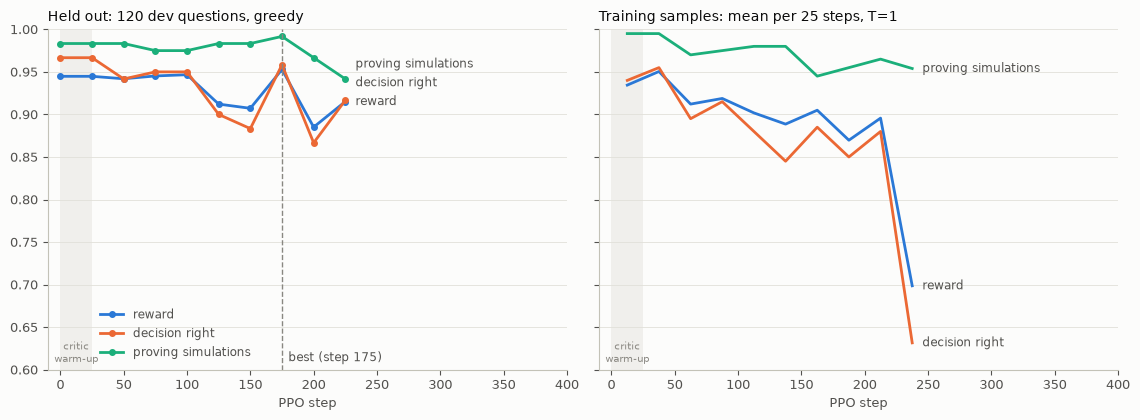

In [7]:
import matplotlib.pyplot as plt

run = RUNS / "ppo-s0"
evals = rows_of(run / "eval.jsonl")
metrics = rows_of(run / "metrics.jsonl")
ending = json.loads((run / "ending.json").read_text())
print(ending)
print(f"\n{'step':>5} {'reward':>7} {'decision':>9} {'proving':>8} {'violations':>11} {'values':>7} {'parses':>7} {'critic - clock':>15}")
for e in evals:
    c = e["components"]
    crit = e["critic_residual_median"]
    print(f"{e['step']:>5} {e['reward']:>7.3f} {e['decision_correct']:>9.3f} {e['evidence']:>8.3f} {c['violations']:>11.3f} "
          f"{c['values']:>7.3f} {e['answer_found']:>7.3f} {'-' if crit is None else f'{crit:+.3f}':>15}")
win = []
for a in range(0, ending["stopped_at"], 25):
    w = [r for r in metrics if a <= r["step"] < a + 25]
    if w:
        win.append((a + 12.5, st.mean(r["reward_mean"] for r in w), st.mean(r["decision_correct"] for r in w),
                    st.mean(r["evidence"] for r in w)))
ahead = [r for r in metrics if r["step"] >= 25 and r["value_ev"] is not None and r["value_ev_position"] is not None]
print(f"\nactor steps where the critic explains the return better than the position clock: "
      f"{sum(r['value_ev'] > r['value_ev_position'] for r in ahead)}/{len(ahead)}")
late = [r for r in metrics if r["step"] >= ending["stopped_at"] // 2]
print(f"KL to the seed per token, second half of the run: {st.mean(r['kl_mean'] for r in late):.4f}; "
      f"sampled call fidelity: {st.mean(r['calls_fidelity'] for r in late):.3f}")


def dodge(ys, gap=0.022):
    order_ = sorted(range(len(ys)), key=lambda i: ys[i])
    out = list(ys)
    for a, b in zip(order_, order_[1:]):
        out[b] = max(out[b], out[a] + gap)
    return out


series = [("reward", "#2a78d6"), ("decision right", "#eb6834"), ("proving simulations", "#1baf7a")]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True, facecolor="#fcfcfb")
xmax = max(ending["stopped_at"] + 140, 400)
for ax in axes:
    ax.set_facecolor("#fcfcfb")
    ax.axvspan(0, 25, color="#f0efec", lw=0)
    ax.grid(axis="y", color="#e1e0d9", lw=0.6)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#c3c2b7")
    ax.tick_params(colors="#52514e", labelsize=9)
    ax.set_xlabel("PPO step", fontsize=9, color="#52514e")
    ax.text(12.5, 0.605, "critic\nwarm-up", ha="center", va="bottom", fontsize=7.5, color="#898781")
    ax.set_xlim(-10, xmax)
xs = [e["step"] for e in evals]
cols = [[e["reward"] for e in evals], [e["decision_correct"] for e in evals], [e["evidence"] for e in evals]]
for (label, color), ys in zip(series, cols):
    axes[0].plot(xs, ys, color=color, lw=2, marker="o", ms=4, label=label)
for (label, _), y in zip(series, dodge([ys[-1] for ys in cols])):
    axes[0].text(xs[-1] + 8, y, label, color="#52514e", fontsize=8.5, va="center")
axes[0].axvline(ending["best_step"], color="#898781", lw=1, ls="--")
axes[0].text(ending["best_step"] + 5, 0.61, f"best (step {ending['best_step']})", color="#52514e", fontsize=8.5)
axes[0].set_title("Held out: 120 dev questions, greedy", fontsize=10, color="#0b0b0b", loc="left")
wx = [w[0] for w in win]
for (label, color), k in zip(series, (1, 2, 3)):
    axes[1].plot(wx, [w[k] for w in win], color=color, lw=2, label=label)
for (label, _), y in zip(series, dodge([win[-1][k] for k in (1, 2, 3)])):
    axes[1].text(wx[-1] + 8, y, label, color="#52514e", fontsize=8.5, va="center")
axes[1].set_title("Training samples: mean per 25 steps, T=1", fontsize=10, color="#0b0b0b", loc="left")
axes[0].set_ylim(0.60, 1.0)
axes[0].legend(loc="lower left", fontsize=8.5, frameon=False, labelcolor="#52514e", bbox_to_anchor=(0.08, 0.0))
fig.tight_layout()
fig.savefig(HERE / "05_units_and_scans_curves.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

## Held out

The best checkpoint and the seed alone, greedy, answers stopped at their closing brace, on test and
on holdout_shift; then the same item-by-item decomposition as 04's, on both notebooks' policies.

PPO adds +0.004 reward on test
(McNemar p = 1.00) and +0.040
on holdout_shift (p = 0.12).


== test (240 questions): seed -> PPO   (whole answer right: 0.817 -> 0.846)
                                   reward   decision right    proving sims          values        parses
   all                    0.916 -> 0.920   0.908 -> 0.908   0.983 -> 0.988   0.767 -> 0.765   0.99 -> 0.99
   ro_check               0.976 -> 0.977   0.975 -> 0.975   1.000 -> 0.975   0.950 -> 0.975   1.00 -> 0.97
   ro_membrane            0.945 -> 0.947   0.950 -> 0.950   0.975 -> 0.950   0.750 -> 0.762   0.97 -> 0.97
   ro_scan_area           0.818 -> 0.793   0.750 -> 0.725   1.000 -> 1.000   0.713 -> 0.650   1.00 -> 1.00
   ro_scan_pressure       0.887 -> 0.919   0.925 -> 0.925   0.950 -> 1.000   0.613 -> 0.688   1.00 -> 1.00
   swro_check             0.933 -> 0.962   0.900 -> 0.975   1.000 -> 1.000   0.925 -> 0.875   1.00 -> 1.00
   swro_option            0.936 -> 0.924   0.950 -> 0.900   0.975 -> 1.000   0.650 -> 0.637   0.97 -> 1.00
   unit level 0           0.956 -> 0.960   0.971 -> 0.971   1.000 -> 1

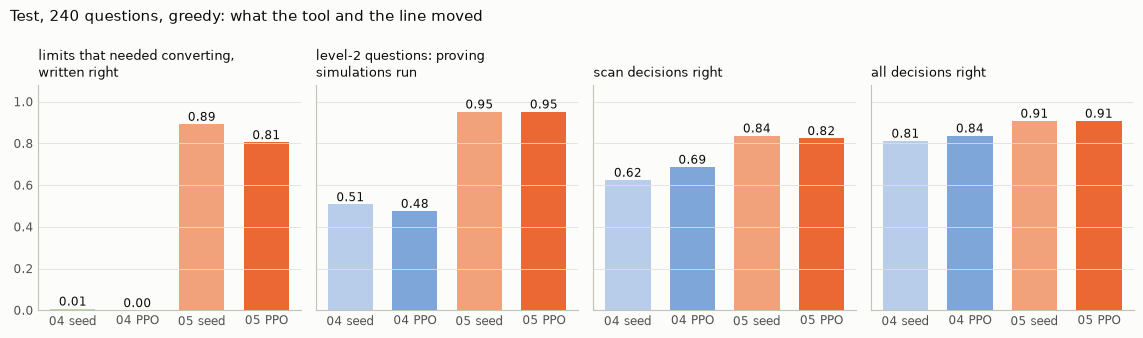

In [8]:
def mcnemar(b, c):
    n = b + c
    return 1.0 if n == 0 else min(1.0, 2 * sum(math.comb(n, i) for i in range(min(b, c) + 1)) / 2 ** n)


def exact(ep):
    """The whole answer right: it parses, the decision, the violations and every number are right."""
    s, c = ep["score"], ep["score"]["components"]
    return bool(s["decision_correct"]) and c.get("format", 0) == 1 and c.get("violations", 1) == 1 and c.get("values", 1) == 1


seed_dir, best_dir = RUNS / "label-seed-pc2" / "epoch3", run / "best"
for split in ("test", "holdout_shift"):
    sp, bp = seed_dir / f"{split}-T0-stop.episodes.jsonl", best_dir / f"{split}-T0-stop.episodes.jsonl"
    rs, rb = nw.episode_report(sp, split), nw.episode_report(bp, split)
    ex = {}
    for who, path in (("seed", sp), ("ppo", bp)):
        ex[who] = collections.defaultdict(lambda: [0, 0])
        for r in rows_of(path):
            c = cases_of(split)[r["id"]]
            for key in ("all:", f"family:{c['family']}", f"level:{c['level']}"):
                ex[who][key][0] += exact(r)
                ex[who][key][1] += 1
    print(f"== {split} ({rs['all:']['n']} questions): seed -> PPO   (whole answer right: "
          f"{ex['seed']['all:'][0] / ex['seed']['all:'][1]:.3f} -> {ex['ppo']['all:'][0] / ex['ppo']['all:'][1]:.3f})")
    print(f"   {'':22} {'reward':>15} {'decision right':>16} {'proving sims':>15} {'values':>15} {'parses':>13}")
    for key in ["all:"] + [k for k in rs if k != "all:"]:
        a, b = rs[key], rb[key]
        name = "all" if key == "all:" else key.replace("family:", "").replace("level:", "unit level ")
        print(f"   {name:22} {a['reward']:.3f} -> {b['reward']:.3f}   {a['decision_correct']:.3f} -> {b['decision_correct']:.3f}"
              f"   {a['evidence']:.3f} -> {b['evidence']:.3f}   {a['values']:.3f} -> {b['values']:.3f}"
              f"   {a['answer_found']:.2f} -> {b['answer_found']:.2f}")
    s_rows = {r["id"]: r for r in rows_of(sp)}
    b_rows = {r["id"]: r for r in rows_of(bp)}
    only_b = sum(b_rows[i]["score"]["decision_correct"] and not s_rows[i]["score"]["decision_correct"] for i in b_rows)
    only_s = sum(s_rows[i]["score"]["decision_correct"] and not b_rows[i]["score"]["decision_correct"] for i in b_rows)
    print(f"   decisions right only under PPO {only_b}, only under the seed {only_s}: McNemar p = {mcnemar(only_b, only_s):.2f}\n")
dev_all = nw.episode_report(best_dir / "dev-T0-stop.episodes.jsonl", "dev")["all:"]
print(f"best checkpoint on all 240 dev questions: reward {dev_all['reward']:.3f} "
      f"(chosen at {ending['best_reward']:.3f} on 120 of them)\n")

# The two notebooks on the test questions they share word for word.
test05, test04 = cases_of("test"), cases_of("test", nw.DATA_04)
same = {i for i in test05 if test05[i]["prompt"] == test04[i]["prompt"]}
print(f"on the {len(same)} test questions identical in 04 and 05:")
policies = (("04 seed", RUNS04 / "label-seed-pc2" / "epoch3"), ("04 PPO", RUNS04 / "ppo-s0" / "best"),
            ("05 seed", seed_dir), ("05 PPO", best_dir))
for name, d in policies:
    r = [e for e in rows_of(d / "test-T0-stop.episodes.jsonl") if e["id"] in same]
    print(f"   {name:8} reward {st.mean(e['score']['total'] for e in r):.3f}   decisions {st.mean(e['score']['decision_correct'] for e in r):.3f}"
          f"   whole answer {st.mean(float(exact(e)) for e in r):.3f}   proving simulations {st.mean(float(e['score']['evidence']) for e in r):.3f}")
print()
d05 = {}
for name, d in (("05's seed, test", seed_dir), ("05's PPO best, test", best_dir)):
    d05[name] = show(name, d / "test-T0-stop.episodes.jsonl", test05)
    print()

# Figure: the four policies on test, on the four things this notebook set out to move.
names = ["04 seed", "04 PPO", "05 seed", "05 PPO"]
dec = [d04["04's label seed, test"], d04["04's PPO best, test"], d05["05's seed, test"], d05["05's PPO best, test"]]
def share(c_, k, tot):
    return c_[0].get(k, 0) / max(1, c_[0].get(tot, 0))
def lvl2(c_):
    L = c_[1][2]
    return L["evidence"] / L["n"]
def scans(name, d):
    r = [e for e in rows_of(d / "test-T0-stop.episodes.jsonl") if e["family"].startswith("ro_scan")]
    return st.mean(e["score"]["decision_correct"] for e in r)
def overall(name, d):
    r = rows_of(d / "test-T0-stop.episodes.jsonl")
    return st.mean(e["score"]["decision_correct"] for e in r)
panels = [("limits that needed converting,\nwritten right", [share(c, "  written right", "limits needing conversion") for c in dec]),
          ("level-2 questions: proving\nsimulations run", [lvl2(c) for c in dec]),
          ("scan decisions right", [scans(n, d) for n, d in policies]),
          ("all decisions right", [overall(n, d) for n, d in policies])]
fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.4), sharey=True, facecolor="#fcfcfb")
colors = ["#b8cde9", "#7fa6d8", "#f2a27a", "#eb6834"]
for ax, (title, ys) in zip(axes, panels):
    ax.set_facecolor("#fcfcfb")
    ax.bar(range(4), ys, color=colors, width=0.7)
    for i, y in enumerate(ys):
        ax.text(i, y + 0.015, f"{y:.2f}", ha="center", fontsize=8.5, color="#0b0b0b")
    ax.set_xticks(range(4), names, fontsize=8.5, color="#52514e")
    ax.set_title(title, fontsize=9.5, color="#0b0b0b", loc="left")
    ax.set_ylim(0, 1.08)
    ax.grid(axis="y", color="#e1e0d9", lw=0.6)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#c3c2b7")
    ax.tick_params(colors="#52514e", labelsize=8.5, length=0)
fig.suptitle("Test, 240 questions, greedy: what the tool and the line moved", fontsize=10.5, color="#0b0b0b", x=0.01, ha="left")
fig.tight_layout()
fig.savefig(HERE / "05_units_and_scans_errors.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

## Summary

* Two of 04's three remaining error sources were things a 0.8B model cannot do in its head -- convert
  a unit to 0.5%, and hold the question's objective while reading its own verdicts. A tool for the
  first and a copy line for the second moved the seed alone past 04's converged PPO.
* PPO from that seed did not add to it. Its evaluations never left the start's neighbourhood, its
  sampled reward fell from the first window on, and its tool gate stopped it when the calls the seed
  had taught began to go. Held out, the best checkpoint and the seed are compared above.
* What remains is in the decomposition, and it is no longer units: misread simulated values and
  comparisons between numbers the policy wrote right.
